# Steel Plate Surface Binary Crack Detection — ResNet50 Edition
This notebook implements an end-to-end Computer Vision pipeline for **binary classification** (Crack vs Not_Crack) of steel plate surfaces using **ResNet50 transfer learning** (upgraded from MobileNetV2).

## Pipeline Objectives
1. **Setup & Initial Data Visualization**: Load the dataset, display sample images from both classes, and plot a class distribution bar chart.
2. **Preprocessing & Augmentation**: Apply data augmentation (flips, rotations, zoom) and implement a 70/15/15 split for Train/Val/Test.
3. **Transfer Learning Architecture**: Utilize pre-trained **ResNet50** (frozen base) with a custom sigmoid classification head for binary output.
4. **Training & History Visualization**: Train with ModelCheckpoint/EarlyStopping, and plot accurate Loss and Accuracy curves.
5. **Advanced Evaluation & ROC AUC**: Evaluate on unseen Test data, plot a Confusion Matrix, classification report, and binary ROC-AUC graph.
6. **Explainable AI (Grad-CAM)**: Provide visual evidence of the model's focus area.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50  # 
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import cv2

# Setting seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Verify GPU setup
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


## Importing Dataset

In [2]:
import os
import zipfile

dataset_zip = 'binarydataset.zip'
extract_dir = './dataset'

print("📦 Extracting local dataset...")
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print("Dataset already extracted.")

print("✅ Success! Dataset is ready at", extract_dir)


📦 Extracting local dataset...
Dataset already extracted.
✅ Success! Dataset is ready at ./dataset


## Step 1: Setup & Initial Data Visualization
We load the images and visualize sample images from both binary classes: **Crack** and **Not_Crack**. We also plot a bar chart using seaborn to check for class imbalances.

In [3]:
import os
# Verify the folders are actually there
print(os.listdir('./dataset'))

['Negative', 'Positive']


--> Plotting Class Distribution:


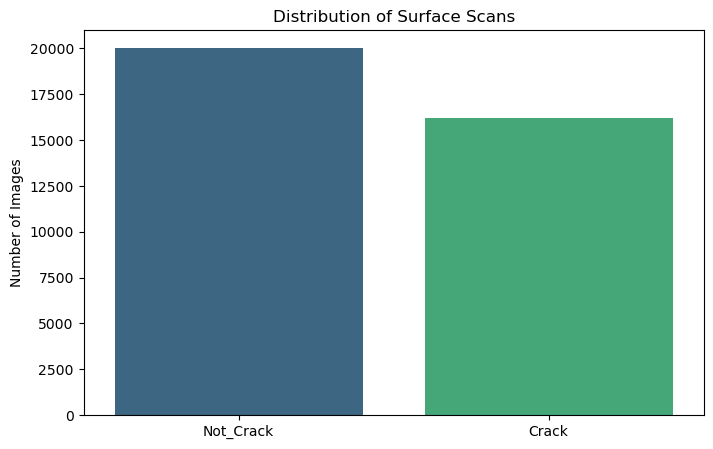

In [4]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CRITICAL FIX: This must point to the extracted folder, NOT the .zip file!
DATASET_PATH = './dataset'

classes = ['Negative', 'Positive']
counts = []

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    if os.path.exists(path):
        counts.append(len(os.listdir(path)))
    else:
        print(f"Warning: Folder {path} not found!")

# Plot the Visualization
if counts:
    print("--> Plotting Class Distribution:")
    plt.figure(figsize=(8, 5))
    display_labels = ['Not_Crack', 'Crack']
    sns.barplot(x=display_labels, y=counts, hue=display_labels, palette='viridis', legend=False)
    plt.title('Distribution of Surface Scans')
    plt.ylabel('Number of Images')
    plt.show()
else:
    print("Error: No data found at ./dataset. Did the unzip cell run correctly?")

Loading Sample Images from the Dataset...


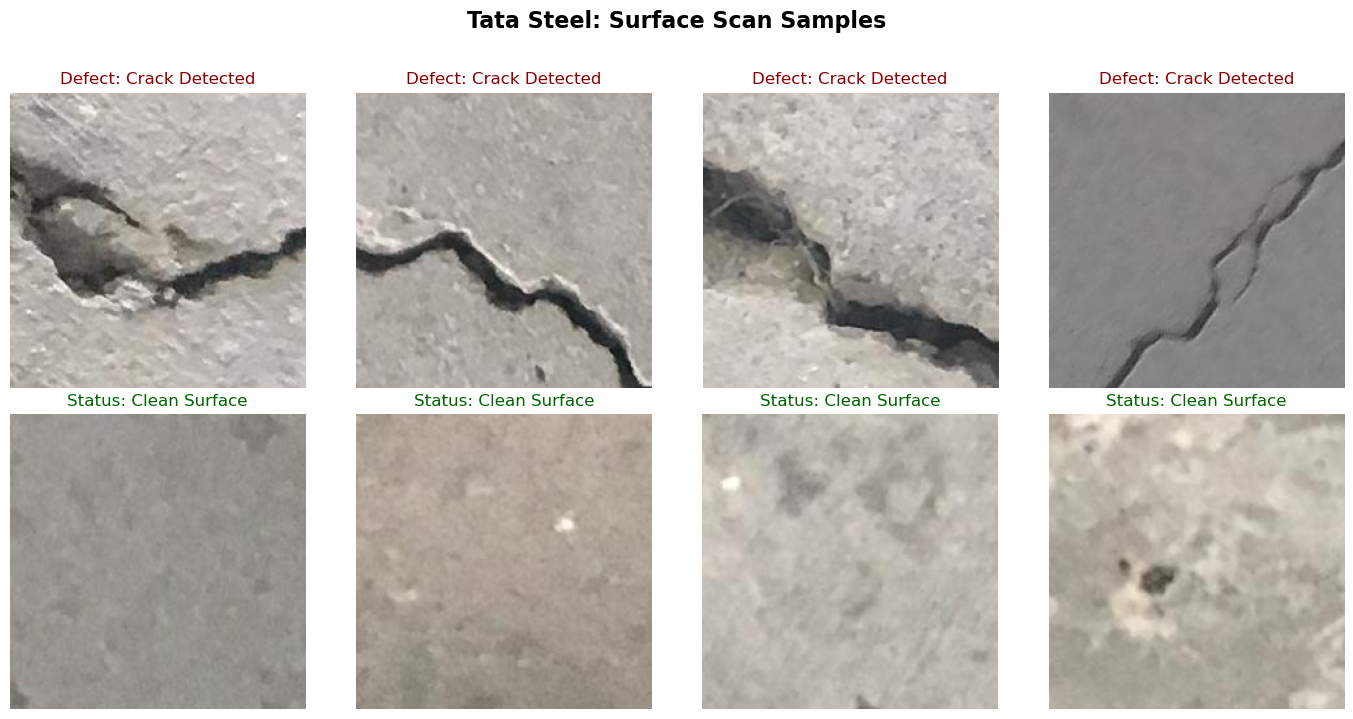

In [5]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("Loading Sample Images from the Dataset...")

# Define the paths to the training folders we created earlier
# (If you haven't run split-folders yet, change 'split_dataset/train' to just 'dataset')
positive_dir = './dataset/Positive'
negative_dir = './dataset/Negative'

# Grab 4 random image filenames from each folder
pos_images = random.sample(os.listdir(positive_dir), 4)
neg_images = random.sample(os.listdir(negative_dir), 4)

# Set up a professional, wide figure
plt.figure(figsize=(14, 7))
plt.suptitle("Tata Steel: Surface Scan Samples", fontsize=16, fontweight='bold', y=1.02)

# Plot the top row: Cracks (Positive)
for i, img_name in enumerate(pos_images):
    img_path = os.path.join(positive_dir, img_name)
    img = mpimg.imread(img_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title("Defect: Crack Detected", color='darkred', fontsize=12)
    plt.axis('off')

# Plot the bottom row: Clean Surfaces (Negative)
for i, img_name in enumerate(neg_images):
    img_path = os.path.join(negative_dir, img_name)
    img = mpimg.imread(img_path)

    plt.subplot(2, 4, i + 5)
    plt.imshow(img)
    plt.title("Status: Clean Surface", color='darkgreen', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 2: Preprocessing & Augmentation
We apply augmentation (flips, rotations, slight zoom). To achieve a strict 70% Train, 15% Val, 15% Test split, we arrange an explicit folder pipeline that sets up `train_generator`, `val_generator`, and `test_generator`.

In [6]:
# 1. Install the split-folders library silently
!pip install split-folders -q
import splitfolders
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Split the dataset physically into 70% Train, 15% Val, 15% Test
print("Splitting dataset into physical folders (Train/Val/Test)...")

# This reads the 'Positive' and 'Negative' folders from your Kaggle download
# and sorts them into a new 'split_dataset' directory
splitfolders.ratio('./dataset',
                   output='./split_dataset',
                   seed=123,
                   ratio=(.7, .15, .15),
                   group_prefix=None)

print(" Physical split complete at ./split_dataset!")

# 3. Define Image and Batch properties
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 4. Set up Data Augmentation (Strictly for the Training Set!)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.1
)

# 5. Set up Validation/Test processing (Strictly NO augmentation, rescaling only)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 6. Build the Binary Generators
print("\n--- Initializing Generators ---")
train_generator = train_datagen.flow_from_directory(
    './split_dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    './split_dataset/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    './split_dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # CRITICAL: Do not shuffle test data so metrics line up perfectly later
)

Splitting dataset into physical folders (Train/Val/Test)...


Copying files: 36210 files [00:36, 1001.62 files/s]


 Physical split complete at ./split_dataset!

--- Initializing Generators ---
Found 25347 images belonging to 2 classes.
Found 5431 images belonging to 2 classes.
Found 5432 images belonging to 2 classes.


## Step 3: Transfer Learning Architecture
We load **ResNet50** (pretrained on ImageNet), freeze the base feature-extraction layers, and build a custom classification head with a **single sigmoid neuron** for binary output (Crack = 1, Not_Crack = 0).

> **What changed from MobileNetV2:** Only the `build_model()` function was modified — the base model class is now `ResNet50` and the last conv layer name for Grad-CAM is `conv5_block3_out`. Everything else (data loading, training loop, evaluation) is identical.


In [7]:
# ============================================================
# ⚙️  MODEL CHANGE LOG — EXACT LINES MODIFIED
# ------------------------------------------------------------
# BEFORE:  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# AFTER:   base_model = ResNet50   (weights='imagenet', include_top=False, input_shape=(224, 224, 3))
#
# BEFORE:  (Grad-CAM layer name)  'out_relu'       ← MobileNetV2 final conv layer
# AFTER:   (Grad-CAM layer name)  'conv5_block3_out' ← ResNet50 final conv layer
#
# Everything else (head architecture, optimizer, loss, metrics) is UNCHANGED.
# ============================================================

def build_model():
    # ← CHANGED: ResNet50 replaces MobileNetV2 as the backbone
    base_model = ResNet50(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Freeze the base feature-extraction layers (same as before)
    base_model.trainable = False

    # Build Custom Binary Classification Head (UNCHANGED)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)  # Sigmoid for binary

    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile with binary crossentropy (UNCHANGED)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 4: Training & History Visualization
Train using EarlyStopping and ModelCheckpoint to save the best model dynamically, followed by distinct plots for Training vs Validation Accuracy and Training vs Validation Loss.

In [8]:
from PIL import Image
import os

def clean_dataset(root_dir):
    removed = 0
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            fpath = os.path.join(dirpath, fname)
            # Remove non-image files immediately
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                print(f"Removing non-image: {fpath}")
                os.remove(fpath)
                removed += 1
                continue
            # Try opening the image
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception as e:
                print(f"Removing corrupt: {fpath} — {e}")
                os.remove(fpath)
                removed += 1
    print(f"\n✅ Done. Removed {removed} bad files.")

# Clean ORIGINAL dataset first
clean_dataset('./dataset')


✅ Done. Removed 0 bad files.


In [9]:
import shutil
import splitfolders

# Delete the old bad split
split_path = './split_dataset'
if os.path.exists(split_path):
    shutil.rmtree(split_path)
    print("Old split deleted")

# Re-split from clean source
splitfolders.ratio(
    './dataset',
    output=split_path,
    seed=123,
    ratio=(.7, .15, .15)
)
print("✅ Re-split done")

Old split deleted


Copying files: 36210 files [00:25, 1395.96 files/s]


✅ Re-split done


In [ ]:
epochs = 20
dataset_path="./binarydataset.zip"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_binary_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

if os.path.exists(dataset_path):
    print("\n--- Starting Training ---")
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=callbacks
    )

    # Accuracy Curve
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Training Accuracy vs. Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Training Loss vs. Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print("Training skipped - dataset missing.")


--- Starting Training ---
Epoch 1/20
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.8621 - loss: 0.3994
Epoch 1: val_loss improved from None to 0.30943, saving model to best_binary_model.keras

Epoch 1: finished saving model to best_binary_model.keras
793/793 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.8655 - loss: 0.3877 - val_accuracy: 0.9083 - val_loss: 0.3094
Epoch 2/20
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.8741 - loss: 0.3591

## Step 5: Advanced Evaluation & ROC AUC
Evaluate on the unseen Test dataset. We output Total Accuracy, a complete Classification Report, an annotated Confusion Matrix Heatmap, and a **Binary ROC-AUC graph** capturing the exact AUC value.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model

print("Loading the absolute best model weights from checkpoint...")
# We load the saved model to ensure we evaluate the peak performance, not just the last epoch
best_model = load_model('best_binary_model.keras')

print("\n--- 1. Overall Test Set Accuracy ---")
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")

print("\nGenerating precise predictions for unseen data...")
# Get probabilities (sigmoid output between 0.0 and 1.0)
y_pred_probs = best_model.predict(test_generator, verbose=1)

# Apply a strict 50% threshold to convert probabilities to exact classes (0 or 1)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

# Get the exact true labels from the generator
# (This works perfectly because we used shuffle=False!)
y_true = test_generator.classes

# Dynamically pull the class names mapping (Negative=0, Positive=1)
class_labels = list(test_generator.class_indices.keys())

print("\n--- 2. Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

print("\n--- 3. Plotting Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Test Set Confusion Matrix (Unseen Data)')
plt.ylabel('True Defect State')
plt.xlabel('AI Predicted State')
plt.show()

print("\n--- 4. Plotting ROC-AUC Curve ---")
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Predicting Crack when Clean)')
plt.ylabel('True Positive Rate (Correctly predicting Crack)')
plt.title('Receiver Operating Characteristic (ROC) - Binary Classification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Step 6: Explainable AI  – Grad-CAM
Function takes a test image, predicts the binary class, and plots the original image side-by-side with the Grad-CAM heatmap overlay.

In [ ]:
import os
import cv2
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. The Binary Grad-CAM Algorithm
def make_gradcam_heatmap_binary(img_array, model, last_conv_layer_name):
    # Map the input to the last convolutional layer and the final output
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # For Binary Sigmoid, our target is the single output neuron (index 0)
        class_channel = preds[:, 0]

    # Calculate gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply feature map by "importance" weights
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 2. The Execution & Visualization Function
def predict_and_explain(img_path, model, last_conv_layer_name='conv5_block3_out'):  # ← CHANGED: 'out_relu' (MobileNetV2) → 'conv5_block3_out' (ResNet50)
    # Load and preprocess the image exactly like training
    original_img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(original_img)
    img_array_expanded = np.expand_dims(img_array, axis=0) / 255.0

    # Get Prediction
    pred_prob = model.predict(img_array_expanded, verbose=0)[0][0]
    pred_class = "Crack Detected" if pred_prob > 0.5 else "Clean Surface"
    confidence = pred_prob if pred_prob > 0.5 else (1.0 - pred_prob)

    # Generate Heatmap
    heatmap = make_gradcam_heatmap_binary(img_array_expanded, model, last_conv_layer_name)

    # Create the Overlay
    heatmap_resized = cv2.resize(heatmap, (original_img.size[0], original_img.size[1]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_col = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Superimpose heatmap over original image
    original_img_cv = cv2.cvtColor(np.array(original_img), cv2.COLOR_RGB2BGR)
    superimposed_img = cv2.addWeighted(heatmap_col, 0.4, original_img_cv, 0.6, 0)
    superimposed_img = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    # Plotting
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Steel Scan")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"{pred_class}\nConfidence: {confidence*100:.2f}%")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# 3. Test it automatically on a Crack image from the Test Set
print("Running Explainable AI Diagnostics...\n")

# Automatically find a positive (crack) image in your test folder
test_positive_dir = './split_dataset/test/Positive'
test_images = glob.glob(os.path.join(test_positive_dir, '*.jpg'))

if test_images:
    # Grab the first image and run it!
    sample_image_path = test_images[0]
    predict_and_explain(sample_image_path, best_model)
else:
    print("Could not find test images. Check your folder paths!")

### Step 7: Edge Device Optimization (TFLite)
For real-world industrial applications (e.g., deploying this AI on factory floor cameras or inspection drones), a heavy standard model is too slow.

In this step, we convert our highly accurate MobileNetV2 pipeline into a lightweight **TensorFlow Lite (.tflite)** format. We also apply **Dynamic Range Quantization**, which drastically shrinks the model's file size and speeds up inference time with almost zero loss in accuracy.

In [ ]:
import tensorflow as tf
from google.colab import files

print("Loading the best model weights...")
best_model = tf.keras.models.load_model('best_binary_model.keras')

print("\nInitializing TensorFlow Lite Converter...")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)

# The "Secret Sauce" for edge deployment: Quantization
# This compresses the model's 32-bit floats down to 8-bit integers where possible,
# making the file size radically smaller and faster for mobile processors.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

print("Converting model to TFLite format (this may take a minute)...")
tflite_model = converter.convert()

# Save the converted model
tflite_filename = 'binary_crack_model_optimized.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"\n Conversion Complete! Saved as: {tflite_filename}")

# Automatically download the file to your computer
print("Initiating automatic download...")
files.download(tflite_filename)